# LOB Signal Backtester — validation-tuned, test-confirmed

Turns each model's per-timestep trend probabilities `(P_up, P_down, P_stationary)`
into threshold-gated long/short trades and asks whether the signal has a **real,
cost-aware, out-of-sample edge**.

**Methodology (no data snooping):**
1. Compute signals on the **validation** and **test** splits.
2. **Grid-search** the entry thresholds `(min_up, min_down)` **on validation only**.
3. For each model, pick the **best horizon** (also on validation).
4. Apply that single chosen `(horizon, min_up, min_down)` **once** to the **test**
   split — that test number is the honest estimate.

So the reported test result was *never* used to choose anything → it is a valid
"my model yields a profitable strategy on unseen data" claim (if positive).

**Execution & costs:** trades **cross the real bid-ask spread** — buy at the ask
(`mid + spread/2`), sell at the bid (`mid − spread/2`), using the swap-corrected
per-bin spread, plus an optional flat `FEE_RATE`. Remaining simplifications: fixed
hold, one position at a time, small size (top-of-book fill, **no market impact**),
same-bar fill (no latency). A **valid signal-research backtest** under the small-order,
taker-execution assumption — not a full deployment model.

**Sections:** 1 Setup · 2 Config · 3 Signal sources · 4 Backtester · 5 Metrics ·
6 Compute signals (val+test) · 7 Grid-search on validation → confirm on test ·
8 Best horizon per model · 9 Plots (best config per model, timestamped) + diagnostics.


## 1. Setup

In [24]:
import os
import sys
import json
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as Fn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src").is_dir():
            return p
    raise RuntimeError(f"Penny repo root not found above {start}")


REPO = _find_repo_root(Path.cwd())
os.chdir(REPO)
sys.path.insert(0, str(REPO / "src"))
print("repo root:", REPO)

from crypto.dataset import build_datasets  # noqa: E402
from crypto.features import extract_features, n_features  # noqa: E402
from crypto.loader import build_cache  # noqa: E402
from models.jumpgatelob import JumpGateLOB  # noqa: E402
from models.dla import DLA  # noqa: E402
from models.tlob import TLOB  # noqa: E402
from models.ctabl import CTABL  # noqa: E402
from models.binctabl import BINCTABL  # noqa: E402
from models.deeplob import DeepLOB  # noqa: E402
from models.alphastablelob import AlphaStableLOB  # noqa: E402
# from models.axiallob import AxialLOB  # commented out for now

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

repo root: /Users/arshia/Projects/Personal/Penny
device: cpu


## 2. Configuration

Backtest parameters, the threshold grid (searched on **validation**), the selection
metric, horizons, and the model registry (all except AxialLOB).


In [25]:
# ---- backtester parameters ----
FEE_RATE = 0.0  # flat exchange fee per round-trip *beyond* the spread (decimal)
# NOTE: the real bid-ask spread is now charged via the fills (mid ± spread/2),
# not a flat number — see run_backtest. BTCIRT's true spread is ~15 bp.
INITIAL_CAPITAL = 100_000.0
HOLD_PERIODS = None  # None → hold = horizon k (aligned); or an int

# ---- threshold search (on VALIDATION) ----
GRID = np.round(np.arange(0.45, 0.86, 0.05), 2)  # min_up / min_down candidates
SELECT_BY = "total_return"  # metric MAXIMISED on validation: "total_return" or "sharpe"
MIN_TRADES = 20  # ignore combos with fewer trades (anti-fluke)

# ---- signal source ----
USE_SYNTHETIC = False  # True → fake data (no checkpoints); False → real models
SYMBOL = "BTCIRT"
FEATURE_MODE = "ofi"
HORIZONS = [10, 20, 50, 100]
BATCH = 256
CHECKPOINT_ROOT = REPO / "checkpoints" / "nobitex" / SYMBOL

MODELS = {
    "jumpgatelob": (JumpGateLOB, "jumpgatelob_"),
    "dla": (DLA, "dla_"),
    "tlob": (TLOB, "tlob_"),
    "ctabl": (CTABL, "ctabl_"),
    "binctabl": (BINCTABL, "binctabl_"),
    "deeplob": (DeepLOB, "deeplob_"),
    "alphastablelob_a1.5": (AlphaStableLOB, "alphastablelob_a1.5_"),
    "alphastablelob_a1.7": (AlphaStableLOB, "alphastablelob_a1.7_"),
    # "axiallob": (AxialLOB, "axiallob_"),
}
VAL_COL = {"total_return": "val_return", "sharpe": "val_sharpe"}[SELECT_BY]

## 3. Signal sources

Each source returns `{"val": ..., "test": ...}`; each split holds aligned arrays
`price, p_up, p_down, p_stat` plus `ts` (µs-UTC) and `dt` (timestamps) at each window's
decision bin.


In [26]:
# ============================================================================
# SYNTHETIC PLACEHOLDER (set USE_SYNTHETIC=False for real models). Random-walk mid +
# fake probs mildly correlated with the future k-bar return; split 50/50 into val/test.
# ============================================================================
def synthetic_signals(k, n=6000, seed=0):
    rng = np.random.default_rng(seed)
    ret = rng.normal(0, 8e-4, n)
    price = 100.0 * np.exp(np.cumsum(ret))
    z = np.roll(ret, -k) / (ret.std() + 1e-9)
    p_up = 1.0 / (1.0 + np.exp(-(2.0 * z + rng.normal(0, 1, n))))
    p_dn = 1.0 / (1.0 + np.exp(-(-2.0 * z + rng.normal(0, 1, n))))
    p_st = np.full(n, 0.6)
    s = p_up + p_dn + p_st
    ts = (np.arange(n) * 10_000_000 + 1_700_000_000_000_000).astype(
        np.int64
    )  # 10 s bins
    dt = pd.to_datetime(ts, unit="us", utc=True)
    full = {
        "price": price,
        "half_spread": price * 7.5e-4,  # ~15 bp round-trip spread (like BTCIRT)
        "p_up": p_up / s,
        "p_down": p_dn / s,
        "p_stat": p_st / s,
        "ts": ts,
        "dt": dt,
    }
    cut = n // 2

    def sub(a, b, split):
        return {
            kk: (vv[a:b] if hasattr(vv, "__len__") else vv) for kk, vv in full.items()
        } | {"tag": "synthetic", "k": k, "split": split}

    return {"val": sub(0, cut, "val"), "test": sub(cut, n, "test")}

In [27]:
# ---- real model loader (val + test signals with timestamps) ----
def _run_config(run_dir: Path):
    cj = run_dir / "config.json"
    if cj.exists():
        try:
            return json.loads(cj.read_text())
        except Exception:
            pass
    return None


def find_checkpoint(prefix: str, k: int):
    if not CHECKPOINT_ROOT.exists():
        return None
    hits = [
        r
        for r in sorted(CHECKPOINT_ROOT.iterdir())
        if r.is_dir()
        and r.name.startswith(prefix)
        and (c := _run_config(r))
        and c.get("feature_mode") == FEATURE_MODE
        and c.get("symbol") == SYMBOL
        and c.get("label_k") == k
    ]
    return str(hits[-1]) if hits else None


def _corrected_half_spread(cfg):
    """bin -> half-spread, with the swapped Nobitex bid/ask fixed (|ask - bid| / 2)."""
    pq = Path(cfg["data_dir"]) / f"{cfg['symbol']}.parquet.gz"
    d = pd.read_parquet(pq, columns=["bin", "bids[0].price", "asks[0].price"])
    d = d.drop_duplicates("bin")
    b0 = d["bids[0].price"].to_numpy(float)
    a0 = d["asks[0].price"].to_numpy(float)
    return d.assign(hs=np.abs(a0 - b0) / 2.0).set_index("bin")["hs"]


@torch.no_grad()
def _split_signal(model, ds, mid, ts, hs_series, T_past, tag, k, split):
    centres = np.asarray(ds.starts) + T_past - 1
    tstamp = ts[centres]
    half_spread = hs_series.reindex(tstamp).to_numpy(float)
    probs = []
    for b in DataLoader(ds, batch_size=BATCH, shuffle=False):
        probs.append(Fn.softmax(model.predict(b, DEVICE), dim=1).cpu().numpy())
    probs = np.concatenate(probs)  # cols: 0=down 1=stat 2=up
    return {
        "tag": tag,
        "k": k,
        "split": split,
        "price": mid[centres].astype(float),
        "half_spread": half_spread,
        "p_up": probs[:, 2],
        "p_down": probs[:, 0],
        "p_stat": probs[:, 1],
        "ts": tstamp,
        "dt": pd.to_datetime(tstamp, unit="us", utc=True),
    }


def get_signals(tag: str, k: int):
    cls, prefix = MODELS[tag]
    run = find_checkpoint(prefix, k)
    if run is None:
        raise FileNotFoundError(
            f"no {tag} checkpoint for k={k} under {CHECKPOINT_ROOT}"
        )
    ckpt = torch.load(Path(run) / "best.pt", map_location=DEVICE, weights_only=False)
    cfg = ckpt["config"]
    model = cls(cfg).to(DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    _, val_ds, test_ds, _a, _m = build_datasets(cfg)
    _, mid, ts = build_cache(cfg, extract_features, n_features, tag="lob")
    hs = _corrected_half_spread(cfg)
    T = cfg["T_past"]
    return {
        "val": _split_signal(model, val_ds, mid, ts, hs, T, tag, k, "val"),
        "test": _split_signal(model, test_ds, mid, ts, hs, T, tag, k, "test"),
    }

## 4. Backtester core

Long if `P_up > min_up`, else short if `P_down > min_down`, else flat. Hold exactly
`hold` bars, then **cross the spread** to exit (buy at ask / sell at bid via `mid ± spread/2`), plus an optional `FEE_RATE`. No overlapping positions.


In [28]:
@dataclass
class Trade:
    entry_idx: int
    exit_idx: int
    direction: int  # +1 long, -1 short
    entry_price: float
    exit_price: float
    net_return: float


def run_backtest(
    price, half_spread, p_up, p_down, hold, min_up, min_down, fee=FEE_RATE
):
    """Cross-spread fills: buy at the ask (mid + spread/2), sell at the bid
    (mid - spread/2). `fee` is an optional flat round-trip exchange fee on top."""
    trades = []
    n = len(price)
    i = 0
    while i < n - hold:
        if p_up[i] > min_up:
            direction = 1
        elif p_down[i] > min_down:
            direction = -1
        else:
            i += 1
            continue
        j = i + hold
        # enter by crossing the spread; exit by crossing it back the other way
        entry = float(price[i]) + direction * float(half_spread[i])
        exit_price = float(price[j]) - direction * float(half_spread[j])
        gross = direction * (exit_price - entry) / entry
        trades.append(Trade(i, j, direction, entry, exit_price, gross - fee))
        i = j + 1
    return trades

## 5. Metrics

In [29]:
def compute_metrics(trades, initial=INITIAL_CAPITAL):
    if not trades:
        return (
            {"n_trades": 0, "total_return": -np.inf, "sharpe": -np.inf},
            np.array([initial]),
            np.array([0.0]),
        )
    rets = np.array([t.net_return for t in trades])
    dirs = np.array([t.direction for t in trades])
    wins, losses = rets[rets > 0], rets[rets < 0]
    equity = np.insert(initial * np.cumprod(1.0 + rets), 0, initial)
    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak * 100.0
    m = {
        "n_trades": len(trades),
        "n_long": int((dirs == 1).sum()),
        "n_short": int((dirs == -1).sum()),
        "win_rate": float((rets > 0).mean()),
        "avg_win": float(wins.mean()) if len(wins) else 0.0,
        "avg_loss": float(losses.mean()) if len(losses) else 0.0,
        "profit_factor": (
            float(wins.sum() / abs(losses.sum()))
            if len(losses) and losses.sum() != 0
            else float("inf")
        ),
        "sharpe": (
            float(rets.mean() / rets.std() * np.sqrt(len(rets)))
            if rets.std() > 0
            else 0.0
        ),
        "max_drawdown": float(dd.min()),
        "total_return": float(equity[-1] / initial - 1.0),
        "final_equity": float(equity[-1]),
    }
    return m, equity, dd

## 6. Compute signals (validation + test)

Runs each model once per horizon over both splits and caches the result — the heavy
step. Everything after this is cheap numpy over the cached probabilities.


In [30]:
SIGNALS = {}  # (tag, k) -> {"val": sig, "test": sig}
for tag in MODELS:
    for k in HORIZONS:
        try:
            SIGNALS[(tag, k)] = (
                synthetic_signals(k) if USE_SYNTHETIC else get_signals(tag, k)
            )
            s = SIGNALS[(tag, k)]
            print(
                f"  {tag:<15} k={k:<3} val={len(s['val']['price']):>6}  "
                f"test={len(s['test']['price']):>6}"
            )
        except FileNotFoundError as e:
            print(f"  {tag:<15} k={k:<3} skipped — {e}")
print(f"\ncached {len(SIGNALS)} (model, horizon) signal sets")

2026-07-14 02:14:43.629 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features
2026-07-14 02:14:44.878 | INFO     | crypto.dataset:build_datasets:85 - windows — train:126742 val:27544 test:27444
2026-07-14 02:14:44.893 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features
2026-07-14 02:15:01.747 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features


  jumpgatelob     k=10  val= 27544  test= 27444


2026-07-14 02:15:03.130 | INFO     | crypto.dataset:build_datasets:85 - windows — train:126732 val:27534 test:27434
2026-07-14 02:15:03.145 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features
2026-07-14 02:15:19.786 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features


  jumpgatelob     k=20  val= 27534  test= 27434


2026-07-14 02:15:21.075 | INFO     | crypto.dataset:build_datasets:85 - windows — train:126702 val:27504 test:27404
2026-07-14 02:15:21.086 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features
2026-07-14 02:15:36.514 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features


...

  deeplob         k=20  val= 27534  test= 27434


2026-07-14 02:22:16.363 | INFO     | crypto.dataset:build_datasets:85 - windows — train:126702 val:27504 test:27404
2026-07-14 02:22:16.380 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features
2026-07-14 02:23:05.506 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features


  deeplob         k=50  val= 27504  test= 27404


2026-07-14 02:23:06.864 | INFO     | crypto.dataset:build_datasets:85 - windows — train:126611 val:27454 test:27354
2026-07-14 02:23:06.880 | INFO     | crypto.loader:build_cache:115 - loaded cache 'lob': 184,084 rows, 31 features


  deeplob         k=100 val= 27454  test= 27354
  alphastablelob_a1.5 k=10  skipped — no alphastablelob_a1.5 checkpoint for k=10 under /Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT
  alphastablelob_a1.5 k=20  skipped — no alphastablelob_a1.5 checkpoint for k=20 under /Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT
  alphastablelob_a1.5 k=50  skipped — no alphastablelob_a1.5 checkpoint for k=50 under /Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT
  alphastablelob_a1.5 k=100 skipped — no alphastablelob_a1.5 checkpoint for k=100 under /Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT
  alphastablelob_a1.7 k=10  skipped — no alphastablelob_a1.7 checkpoint for k=10 under /Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT
  alphastablelob_a1.7 k=20  skipped — no alphastablelob_a1.7 checkpoint for k=20 under /Users/arshia/Projects/Personal/Penny/checkpoints/nobitex/BTCIRT
  alphastablelob_a1.7 k=50  skipped — n

## 7. Grid-search on validation → confirm on test

For every `(model, horizon)`: search `(min_up, min_down)` on **validation** (maximise
`SELECT_BY`), then apply the winner **once** to **test**. `val_*` columns are the
in-sample selection scores; `test_*` are the honest out-of-sample results. `bh_return`
is buy-and-hold over the test window for reference.


In [31]:
def _bt(sig, hold, mu, md):
    tr = run_backtest(
        sig["price"], sig["half_spread"], sig["p_up"], sig["p_down"], hold, mu, md
    )
    return tr, compute_metrics(tr)[0]


res_rows, grid_rows = [], []
for (tag, k), s in SIGNALS.items():
    hold = HOLD_PERIODS if HOLD_PERIODS is not None else k
    best = None
    for mu in GRID:
        for md in GRID:
            _, mv = _bt(s["val"], hold, mu, md)
            grid_rows.append(
                {
                    "model": tag,
                    "k": k,
                    "min_up": float(mu),
                    "min_down": float(md),
                    "val_return": mv["total_return"],
                    "val_sharpe": mv["sharpe"],
                    "val_trades": mv["n_trades"],
                }
            )
            if mv["n_trades"] < MIN_TRADES:
                continue
            if best is None or mv[SELECT_BY] > best["m"][SELECT_BY]:
                best = {"mu": float(mu), "md": float(md), "m": mv}
    if best is None:
        continue
    _, mt = _bt(s["test"], hold, best["mu"], best["md"])
    price_t = s["test"]["price"]
    res_rows.append(
        {
            "model": tag,
            "k": k,
            "min_up": best["mu"],
            "min_down": best["md"],
            "hold": hold,
            "val_return": best["m"]["total_return"],
            "val_sharpe": best["m"]["sharpe"],
            "test_return": mt["total_return"],
            "test_sharpe": mt["sharpe"],
            "test_trades": mt["n_trades"],
            "test_win": mt["win_rate"],
            "test_maxdd": mt["max_drawdown"],
            "bh_return": float(price_t[-1] / price_t[0] - 1.0),
        }
    )

results_df = pd.DataFrame(res_rows).sort_values(["model", "k"]).reset_index(drop=True)
grid_df = pd.DataFrame(grid_rows)
if not results_df.empty:
    display(
        results_df.style.format(
            {
                "min_up": "{:.2f}",
                "min_down": "{:.2f}",
                "val_return": "{:+.2%}",
                "val_sharpe": "{:.2f}",
                "test_return": "{:+.2%}",
                "test_sharpe": "{:.2f}",
                "test_win": "{:.2%}",
                "test_maxdd": "{:.2f}",
                "bh_return": "{:+.2%}",
            }
        ).background_gradient(cmap="RdYlGn", subset=["test_return", "test_sharpe"])
    )
else:
    print("no valid results — check checkpoints / MIN_TRADES / USE_SYNTHETIC")

,model,k,min_up,min_down,hold,val_return,val_sharpe,test_return,test_sharpe,test_trades,test_win,test_maxdd,bh_return
0,ctabl,10,0.85,0.85,10,-77.76%,-34.60,-83.13%,-36.87,1166,10.29%,-83.13,+3.83%
1,ctabl,20,0.85,0.85,20,-52.03%,-20.51,-57.51%,-22.97,542,14.39%,-57.51,+3.83%
2,ctabl,50,0.85,0.85,50,-20.98%,-7.36,-21.11%,-8.91,184,23.37%,-21.55,+3.91%
3,ctabl,100,0.85,0.85,100,-5.92%,-2.13,-11.69%,-4.38,109,33.94%,-12.52,+3.93%
4,deeplob,10,0.85,0.85,10,-45.50%,-19.14,-52.91%,-22.52,607,14.33%,-52.91,+3.83%
5,deeplob,20,0.85,0.85,20,-27.53%,-11.10,-34.21%,-14.31,368,22.55%,-34.21,+3.83%
6,deeplob,50,0.85,0.85,50,-3.92%,-1.94,-8.83%,-5.24,102,29.41%,-9.14,+3.91%
7,deeplob,100,0.85,0.85,100,-2.86%,-1.42,-9.16%,-3.88,69,30.43%,-9.86,+3.93%
8,dla,10,0.85,0.85,10,-73.62%,-31.73,-78.80%,-35.39,1052,10.46%,-78.80,+3.83%
9,dla,20,0.85,0.85,20,-55.09%,-21.35,-58.15%,-23.03,588,14.63%,-58.15,+3.83%


## 8. Best configuration per model

For each model, the horizon chosen **on validation** (`SELECT_BY`), with its confirmed
**test** performance. This is the one config per model we plot in section 9.


In [32]:
if not results_df.empty:
    idx = results_df.groupby("model")[VAL_COL].idxmax()
    selected_df = (
        results_df.loc[idx].sort_values(VAL_COL, ascending=False).reset_index(drop=True)
    )
    display(
        selected_df.style.format(
            {
                "min_up": "{:.2f}",
                "min_down": "{:.2f}",
                "val_return": "{:+.2%}",
                "val_sharpe": "{:.2f}",
                "test_return": "{:+.2%}",
                "test_sharpe": "{:.2f}",
                "test_win": "{:.2%}",
                "test_maxdd": "{:.2f}",
                "bh_return": "{:+.2%}",
            }
        ).background_gradient(cmap="RdYlGn", subset=["test_return", "test_sharpe"])
    )
    print("Selection was made on validation; test_* columns are the honest estimate.")
else:
    selected_df = pd.DataFrame()

,model,k,min_up,min_down,hold,val_return,val_sharpe,test_return,test_sharpe,test_trades,test_win,test_maxdd,bh_return
0,jumpgatelob,100,0.85,0.85,100,-2.35%,-1.07,-4.71%,-3.01,44,34.09%,-4.71,+3.93%
1,deeplob,100,0.85,0.85,100,-2.86%,-1.42,-9.16%,-3.88,69,30.43%,-9.86,+3.93%
2,ctabl,100,0.85,0.85,100,-5.92%,-2.13,-11.69%,-4.38,109,33.94%,-12.52,+3.93%
3,tlob,100,0.85,0.85,100,-8.57%,-3.17,-9.30%,-4.26,123,32.52%,-10.68,+3.93%
4,dla,100,0.85,0.85,100,-9.41%,-3.50,-10.77%,-4.85,117,33.33%,-11.76,+3.93%


Selection was made on validation; test_* columns are the honest estimate.


## 9. Plots — best config per model (test set, timestamped)

Two figures per model: a **timestamped time-series** (price+entries, signals, equity,
drawdown) and a **diagnostics** panel (return distribution, edge by hour-of-day,
strategy vs buy-and-hold, long/short split, rolling win-rate, and the validation
threshold landscape with the chosen point starred).


In [33]:
def plot_strategy_time(sig, trades, equity, dd, mu, md, hold):
    dt, price = sig["dt"], sig["price"]
    fig, (a1, a2, a3, a4) = plt.subplots(
        4, 1, figsize=(14, 11), gridspec_kw={"height_ratios": [3, 1.3, 1.5, 0.9]}
    )
    a1.plot(dt, price, lw=0.7, color="black")
    for t in trades:
        a1.plot(
            dt[t.entry_idx],
            price[t.entry_idx],  # marker on the mid line (fill price includes spread)
            marker="^" if t.direction == 1 else "v",
            color="green" if t.net_return > 0 else "red",
            ms=6,
            mec="black",
            mew=0.3,
            ls="none",
        )
    a1.set_ylabel("mid price")
    a1.set_title(
        f"{sig['tag']}  k={sig['k']}  · test ·  min_up={mu:.2f} "
        f"min_down={md:.2f}  hold={hold}  "
        f"spread~{np.nanmedian(2 * sig['half_spread'] / price) * 1e4:.1f}bp  "
        f"fee={FEE_RATE}"
    )
    a2.fill_between(dt, 0, sig["p_up"], color="green", alpha=0.5, step="mid")
    a2.fill_between(dt, 0, -sig["p_down"], color="red", alpha=0.5, step="mid")
    a2.axhline(mu, ls="--", lw=0.8, color="green")
    a2.axhline(-md, ls="--", lw=0.8, color="red")
    a2.axhline(0, lw=0.5, color="grey")
    a2.set_ylim(-1, 1)
    a2.set_ylabel("P(up) / -P(down)")
    eq_times = (
        pd.DatetimeIndex([dt[trades[0].entry_idx]] + [dt[t.exit_idx] for t in trades])
        if trades
        else dt[:1]
    )
    a3.plot(eq_times, equity, color="tab:blue", lw=1.2)
    a3.axhline(INITIAL_CAPITAL, ls="--", lw=0.8, color="grey")
    a3.set_ylabel("equity ($)")
    a4.fill_between(eq_times, 0, dd, color="red", alpha=0.4)
    a4.set_ylabel("drawdown %")
    a4.set_xlabel("time (UTC)")
    for ax in (a1, a2, a3, a4):
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()


def plot_diagnostics(sig, trades, equity, mu, md):
    if not trades:
        print(f"  {sig['tag']} k={sig['k']}: no trades — nothing to diagnose")
        return
    dt = sig["dt"]
    rets = np.array([t.net_return for t in trades]) * 100
    dirs = np.array([t.direction for t in trades])
    hours = np.array([dt[t.entry_idx].hour for t in trades])
    fig, ax = plt.subplots(2, 3, figsize=(16, 8.5))

    a = ax[0, 0]
    a.hist(rets, bins=40, color="steelblue", edgecolor="white")
    a.axvline(0, color="grey", lw=1)
    a.axvline(
        rets.mean(), color="red", ls="--", lw=1, label=f"mean {rets.mean():+.3f}%"
    )
    a.set_title("per-trade net return (%)")
    a.legend(fontsize=8)

    a = ax[0, 1]
    hr = np.arange(24)
    mean_h = [rets[hours == h].mean() if (hours == h).any() else 0.0 for h in hr]
    a.bar(hr, mean_h, color=["green" if v >= 0 else "red" for v in mean_h])
    a.axhline(0, color="grey", lw=0.8)
    a.set_title("mean return by hour of day (UTC)")
    a.set_xlabel("hour")
    a.set_ylabel("mean net %")
    a.set_xticks(range(0, 24, 3))

    a = ax[0, 2]
    bh = (sig["price"] / sig["price"][0] - 1.0) * 100
    eq_times = pd.DatetimeIndex(
        [dt[trades[0].entry_idx]] + [dt[t.exit_idx] for t in trades]
    )
    a.plot(
        eq_times,
        (equity / INITIAL_CAPITAL - 1.0) * 100,
        color="tab:blue",
        lw=1.3,
        label="strategy",
    )
    a.plot(dt, bh, color="grey", lw=1.0, alpha=0.8, label="buy & hold")
    a.axhline(0, color="grey", lw=0.6)
    a.set_title("cumulative return: strategy vs buy&hold")
    a.set_ylabel("%")
    a.legend(fontsize=8)
    a.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    a = ax[1, 0]
    for d, c, lbl in [(1, "green", "long"), (-1, "red", "short")]:
        r = np.where(dirs == d, rets / 100, 0.0)
        a.plot(np.cumprod(1.0 + r), color=c, lw=1.2, label=lbl)
    a.set_title("cumulative return by side")
    a.set_xlabel("trade #")
    a.legend(fontsize=8)
    a.grid(alpha=0.3)

    a = ax[1, 1]
    win = (rets > 0).astype(float)
    W = min(30, len(win))
    if W > 1:
        rw = np.convolve(win, np.ones(W) / W, "valid")
        a.plot(range(W - 1, len(win)), rw, color="purple", lw=1.2)
    a.axhline(0.5, ls="--", color="grey", lw=0.8)
    a.set_ylim(0, 1)
    a.set_title(f"rolling win rate ({W}-trade)")
    a.set_xlabel("trade #")
    a.grid(alpha=0.3)

    a = ax[1, 2]
    d = grid_df[(grid_df["model"] == sig["tag"]) & (grid_df["k"] == sig["k"])]
    if not d.empty:
        piv = d.pivot(index="min_down", columns="min_up", values=VAL_COL).reindex(
            index=GRID, columns=GRID
        )
        im = a.imshow(piv.values, origin="lower", cmap="RdYlGn", aspect="auto")
        a.set_xticks(
            range(len(GRID)), [f"{v:.2f}" for v in GRID], rotation=45, fontsize=7
        )
        a.set_yticks(range(len(GRID)), [f"{v:.2f}" for v in GRID], fontsize=7)
        a.scatter(
            list(GRID).index(mu),
            list(GRID).index(md),
            marker="*",
            s=220,
            color="black",
            edgecolor="white",
            zorder=3,
        )
        a.set_title("validation grid (★ chosen)")
        a.set_xlabel("min_up")
        a.set_ylabel("min_down")
        fig.colorbar(im, ax=a, fraction=0.046)
    fig.suptitle(f"{sig['tag']}  k={sig['k']}  · strategy diagnostics (test)", y=1.00)
    fig.tight_layout()
    plt.show()


=== jumpgatelob  k=100  (min_up=0.85, min_down=0.85, hold=100) — TEST ===
  trades 44 | win 34.1% | return -4.71% | sharpe -3.01 | maxDD -4.71% | buy&hold +3.93%


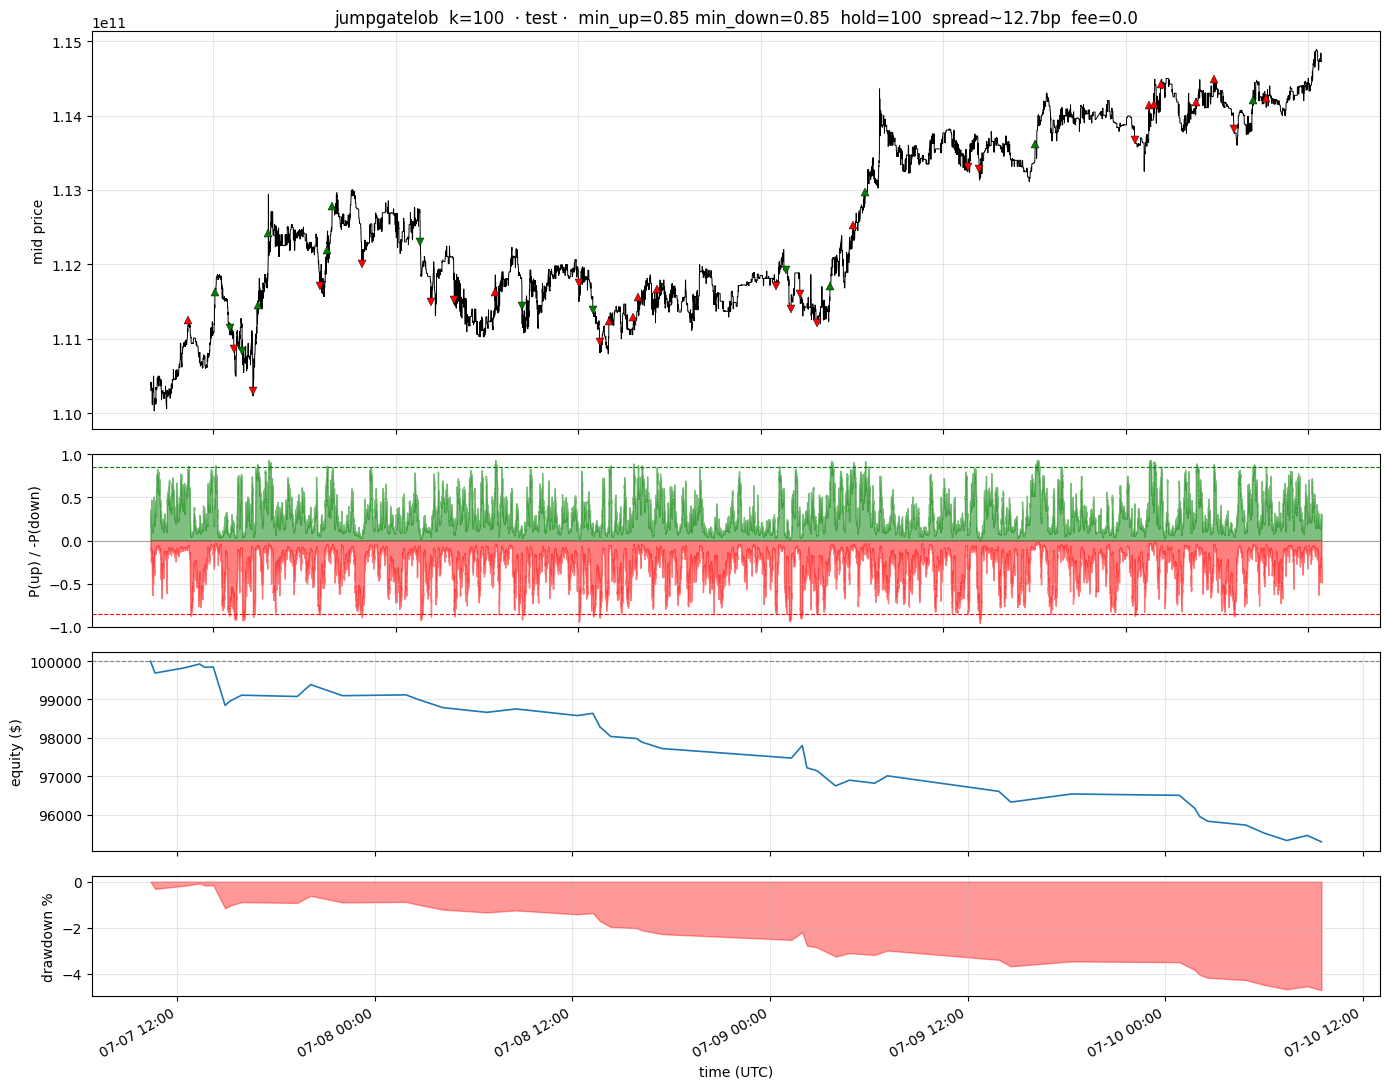

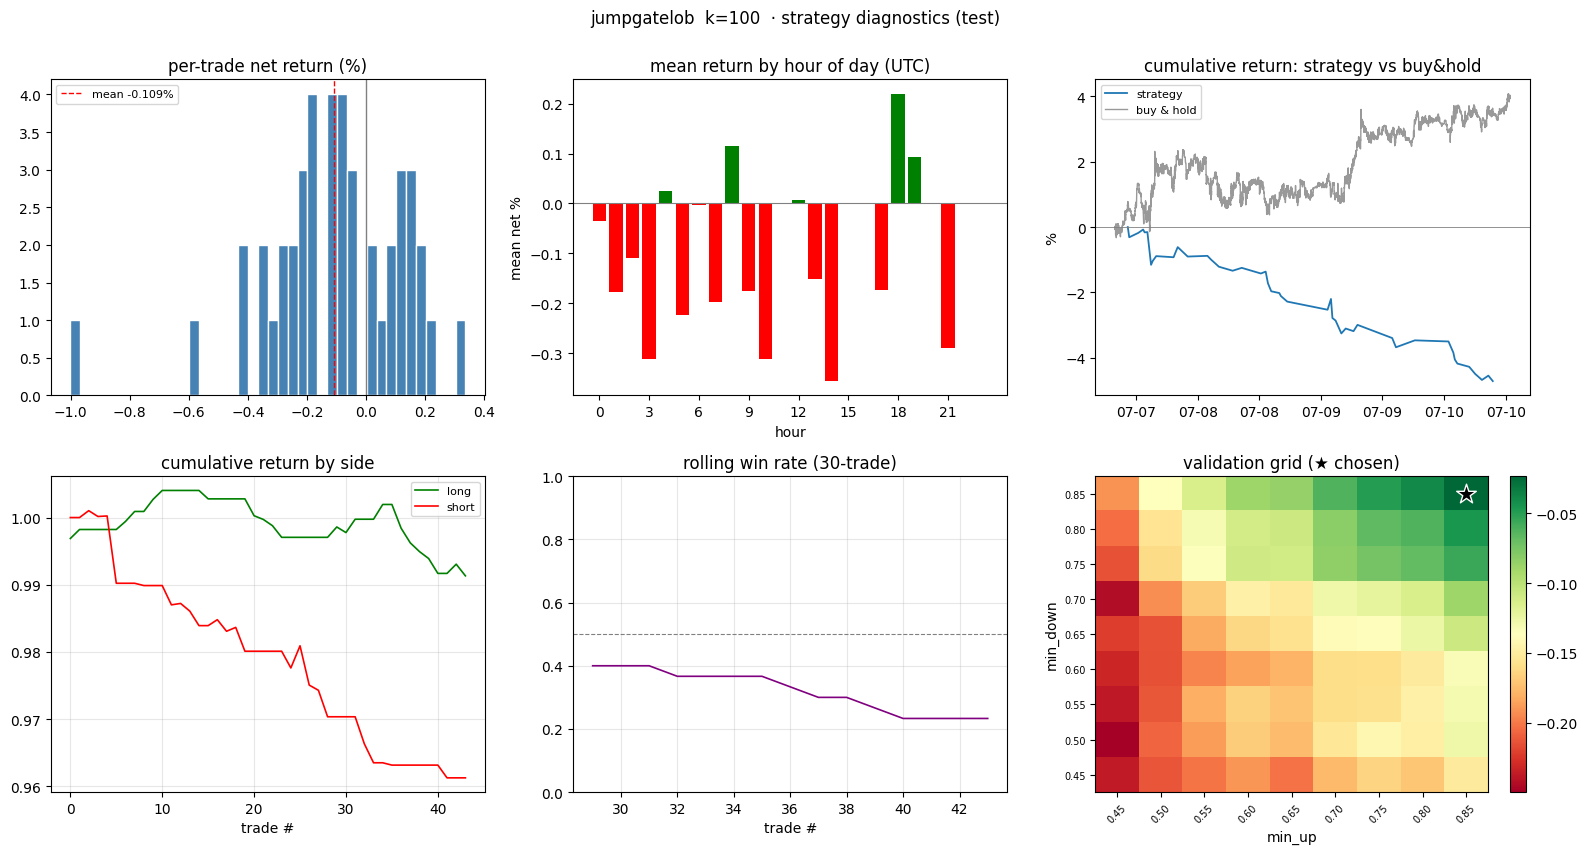


=== deeplob  k=100  (min_up=0.85, min_down=0.85, hold=100) — TEST ===
  trades 69 | win 30.4% | return -9.16% | sharpe -3.88 | maxDD -9.86% | buy&hold +3.93%


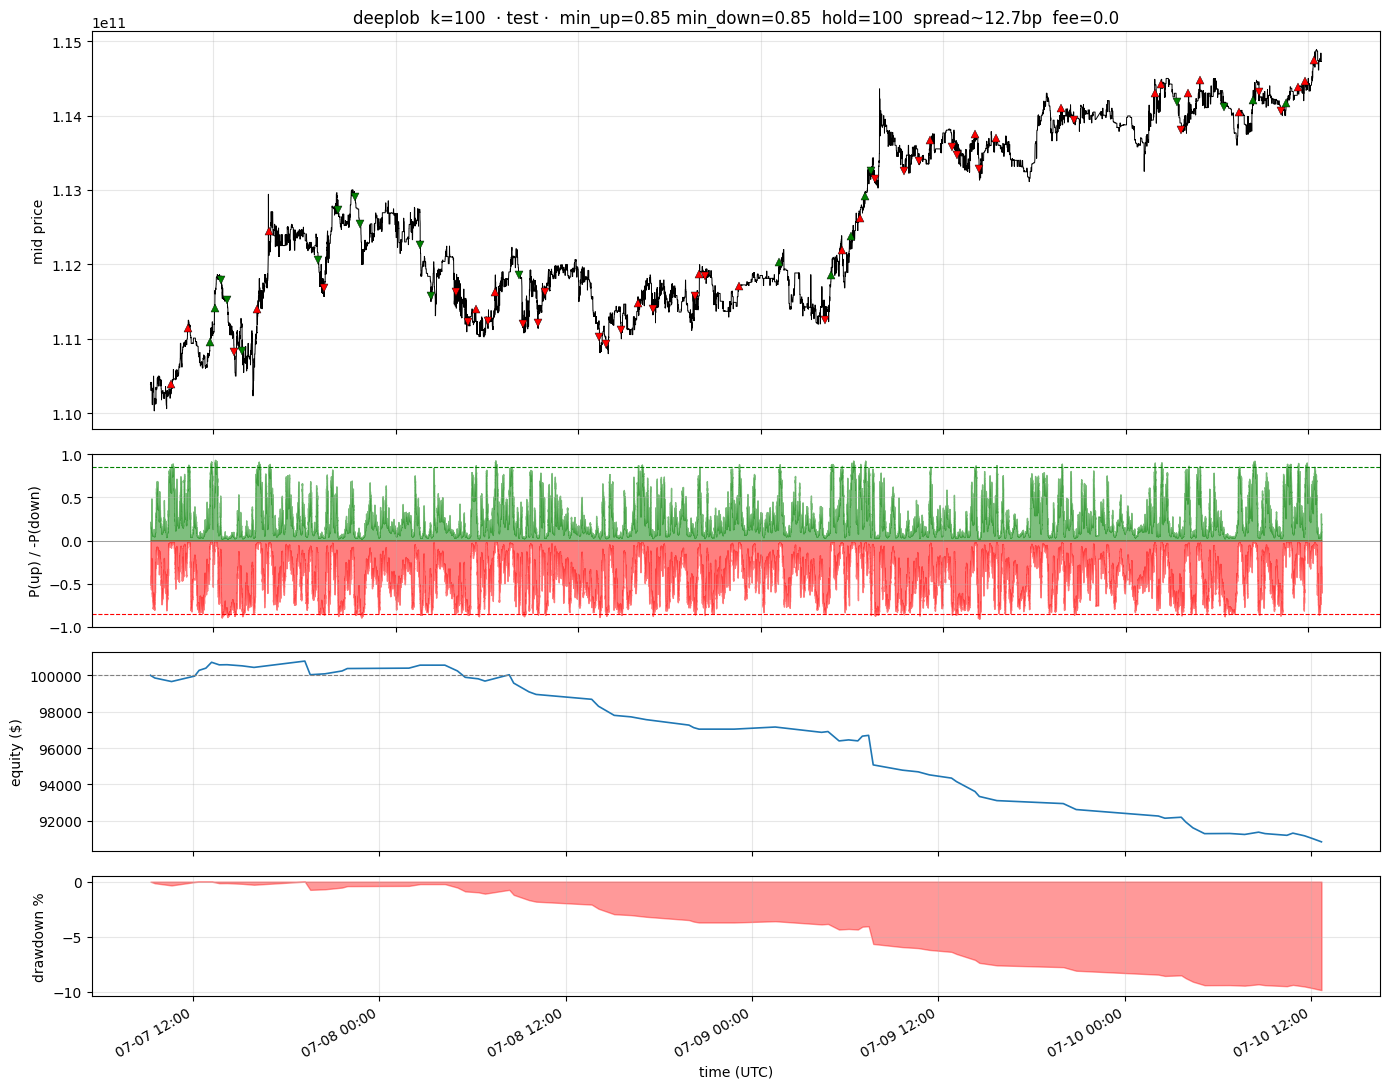

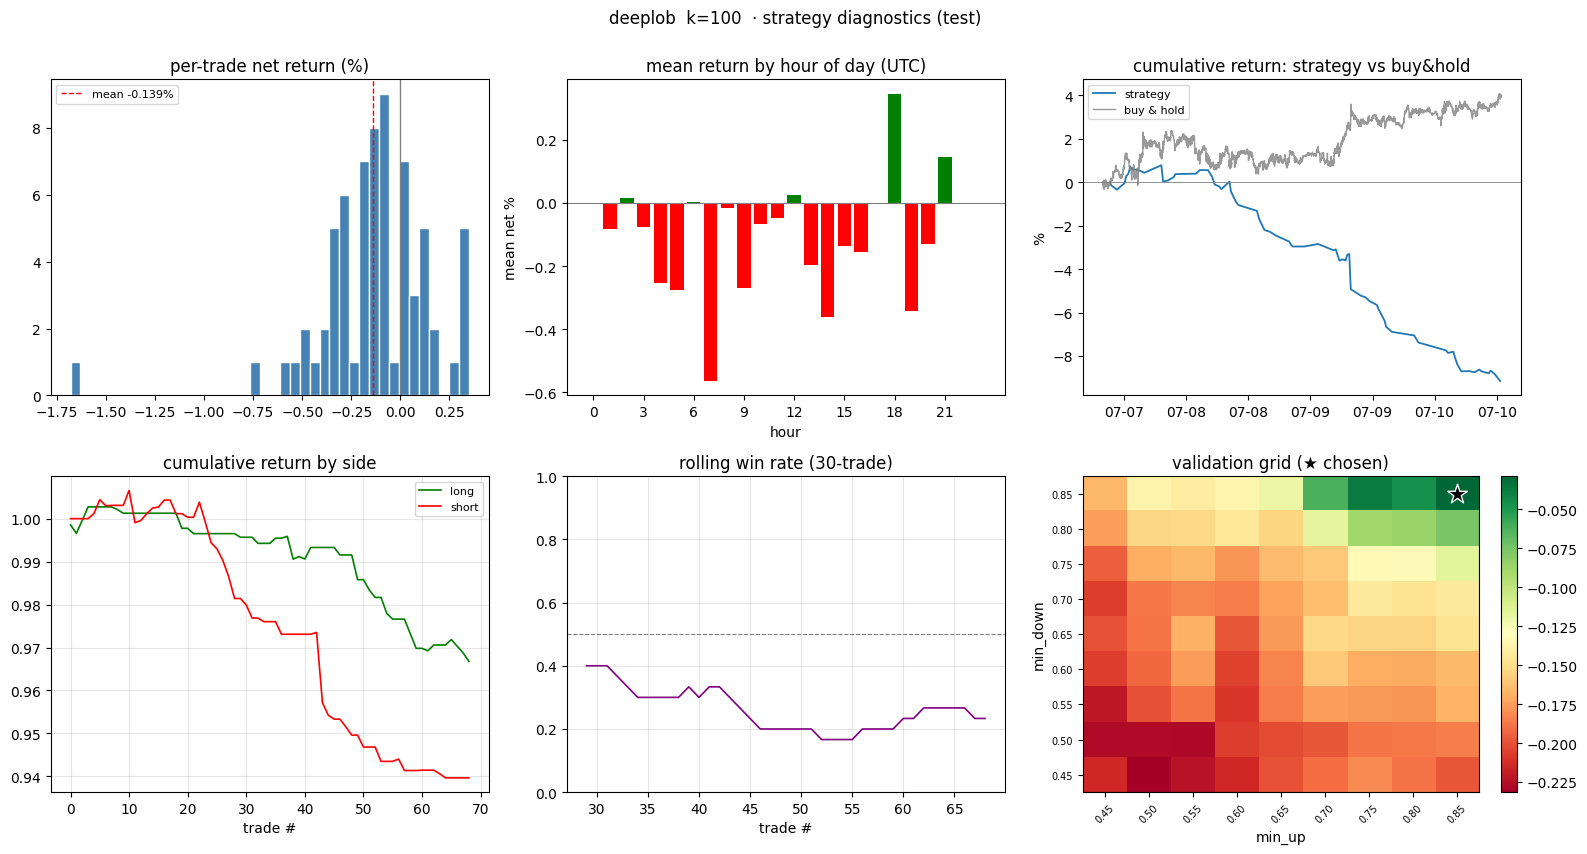


=== ctabl  k=100  (min_up=0.85, min_down=0.85, hold=100) — TEST ===
  trades 109 | win 33.9% | return -11.69% | sharpe -4.38 | maxDD -12.52% | buy&hold +3.93%


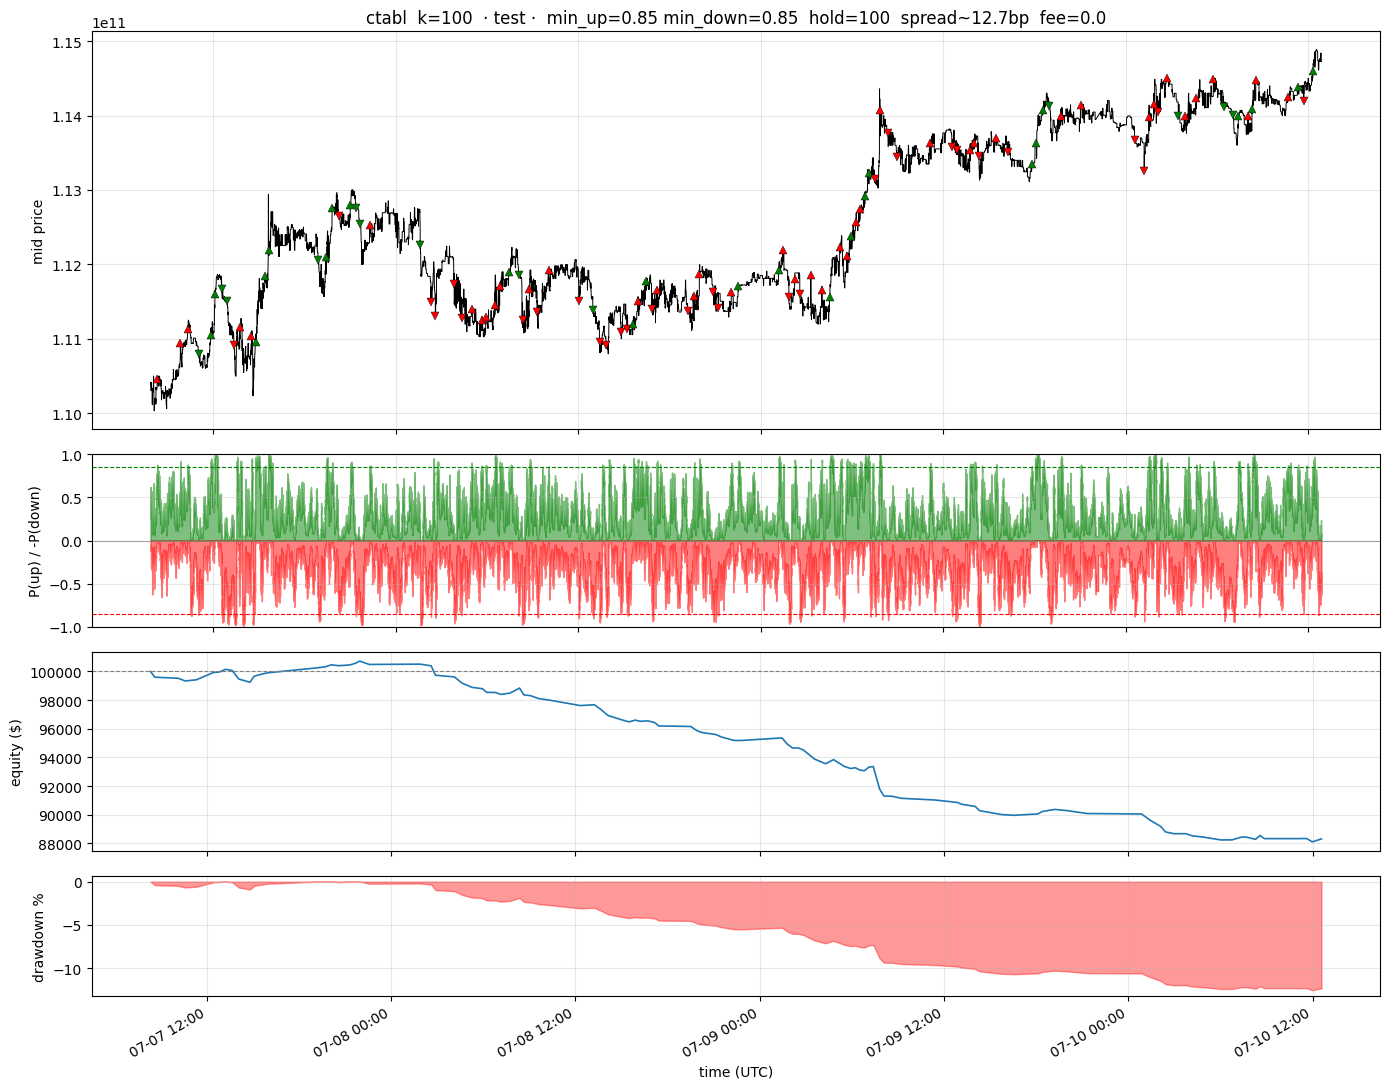

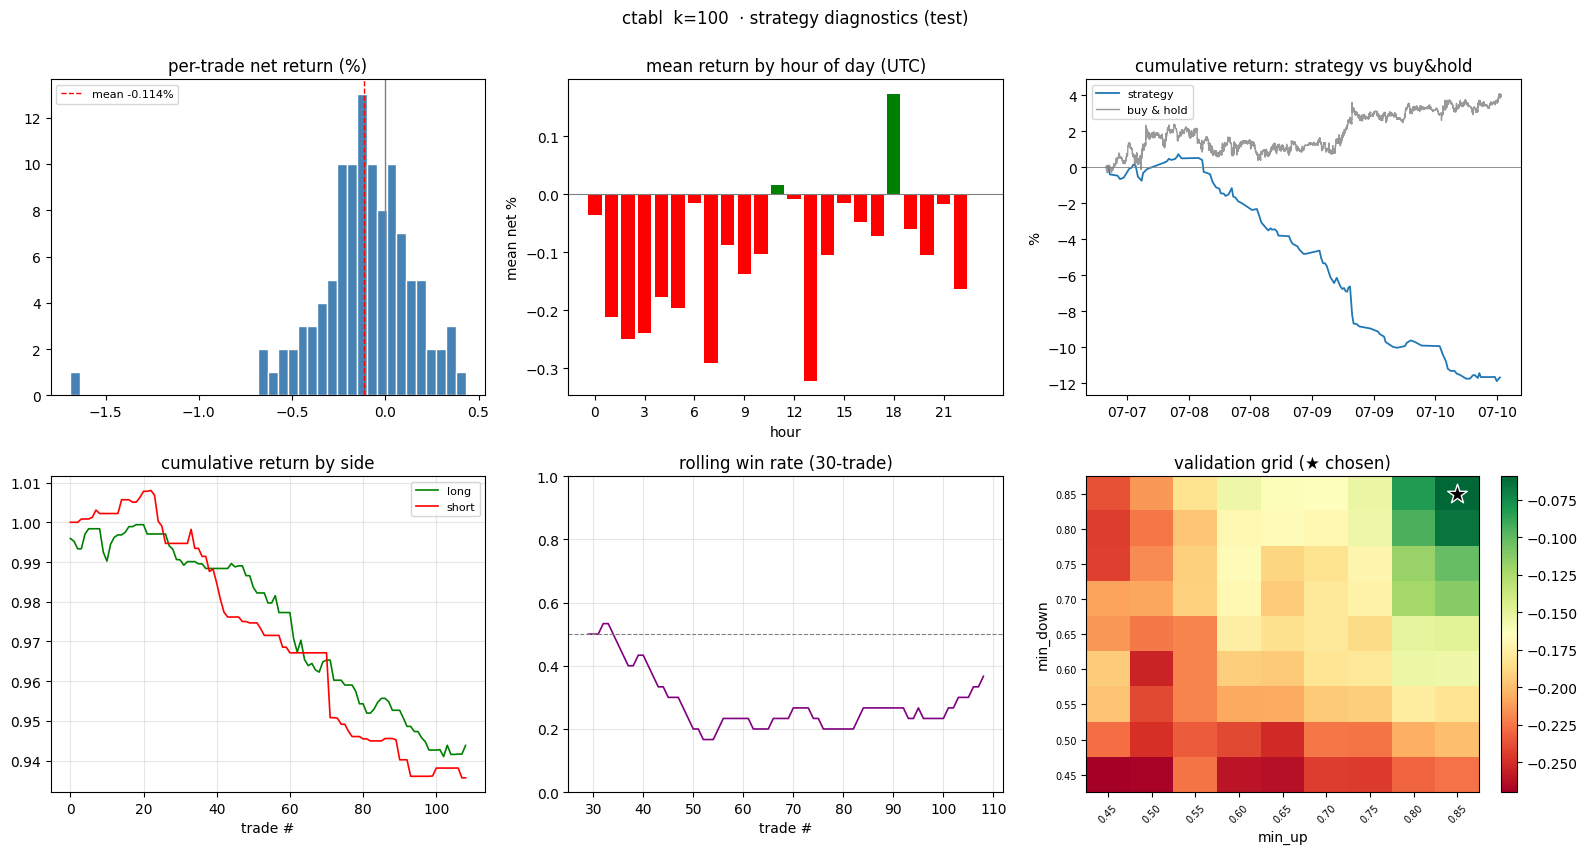


=== tlob  k=100  (min_up=0.85, min_down=0.85, hold=100) — TEST ===
  trades 123 | win 32.5% | return -9.30% | sharpe -4.26 | maxDD -10.68% | buy&hold +3.93%


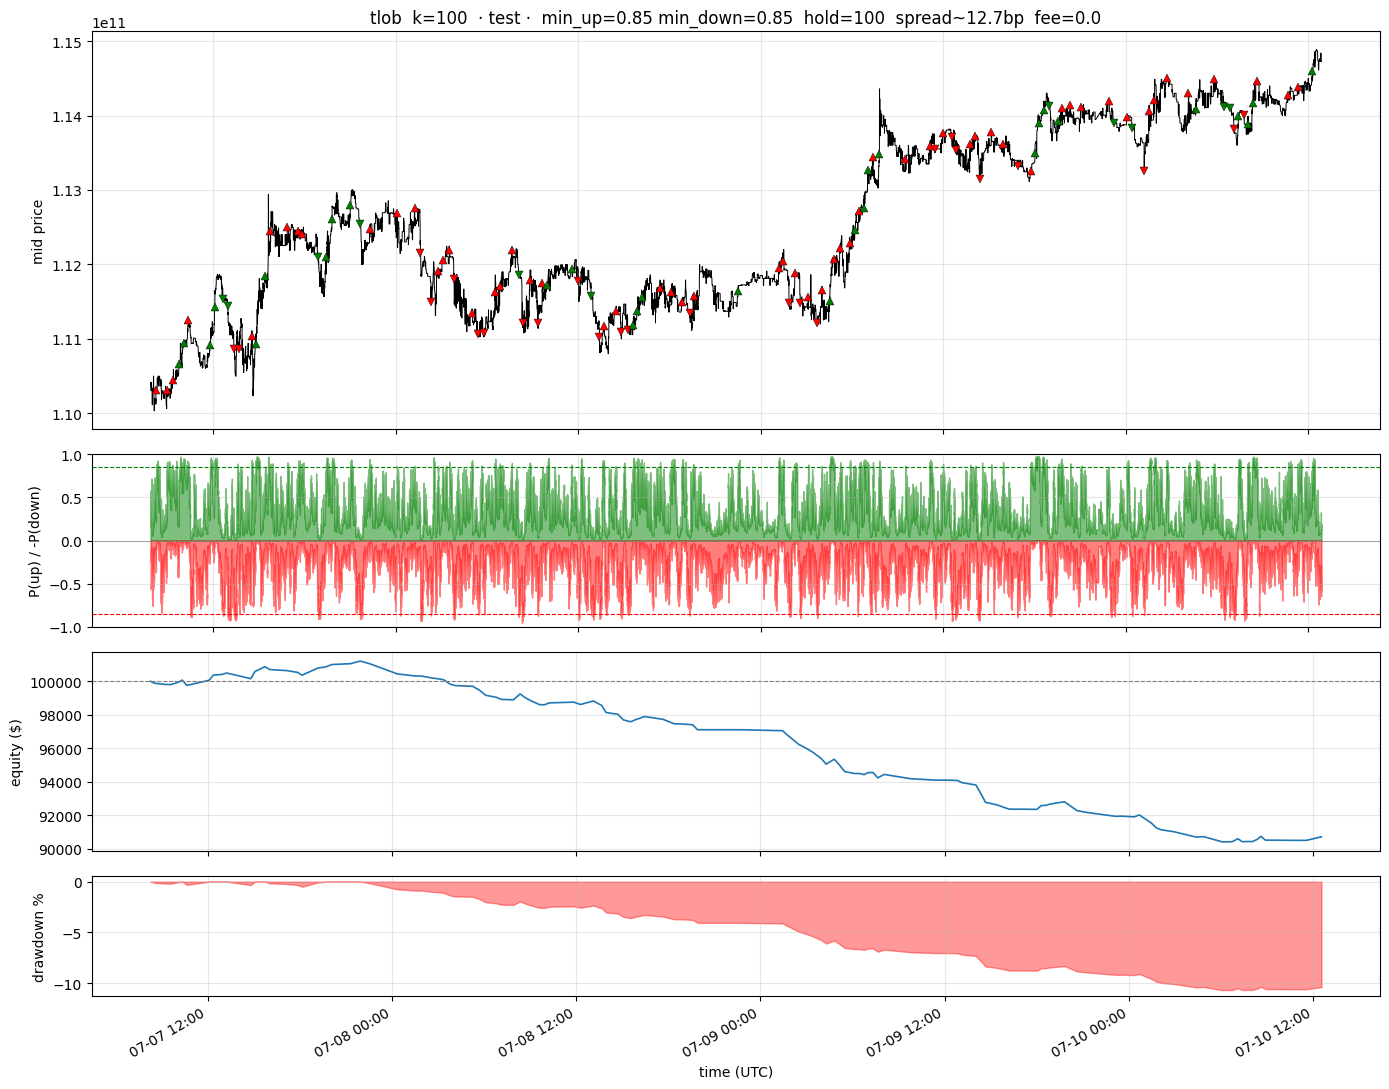

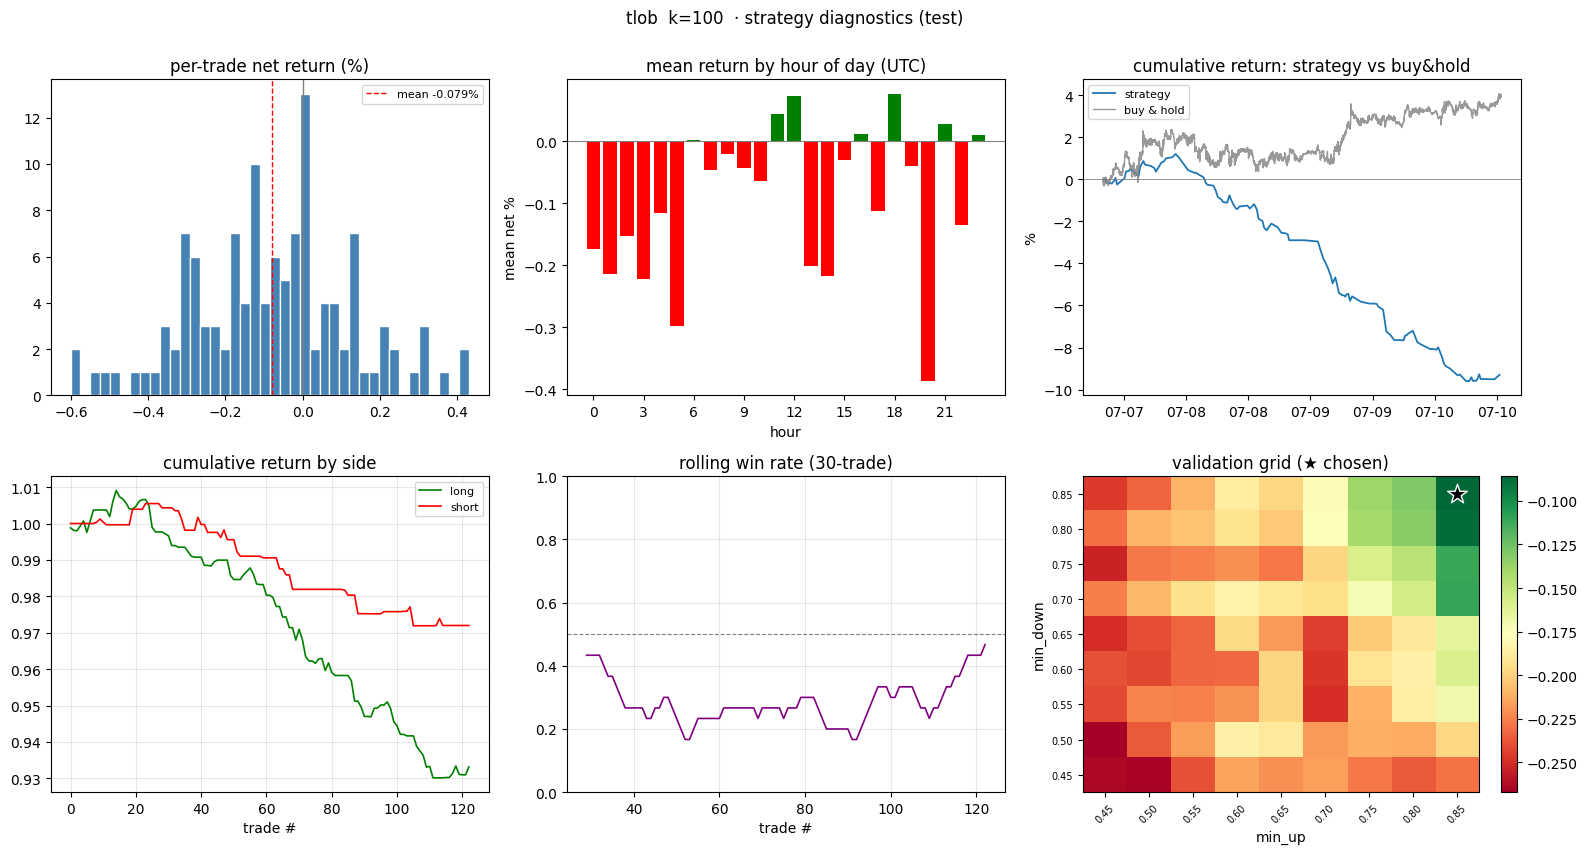


=== dla  k=100  (min_up=0.85, min_down=0.85, hold=100) — TEST ===
  trades 117 | win 33.3% | return -10.77% | sharpe -4.85 | maxDD -11.76% | buy&hold +3.93%


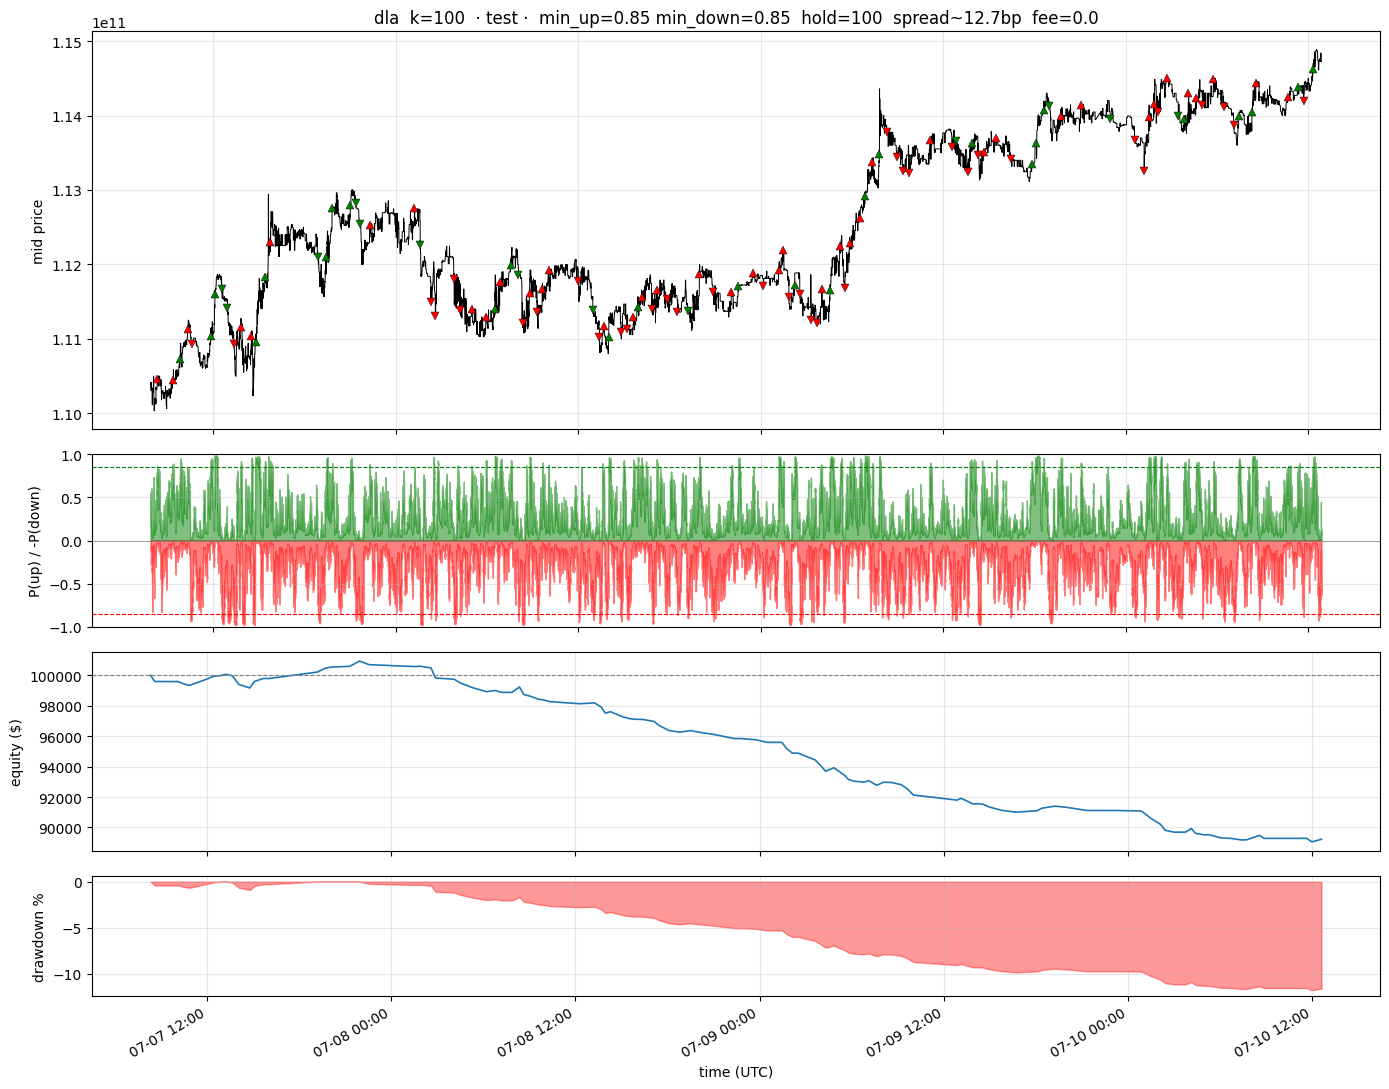

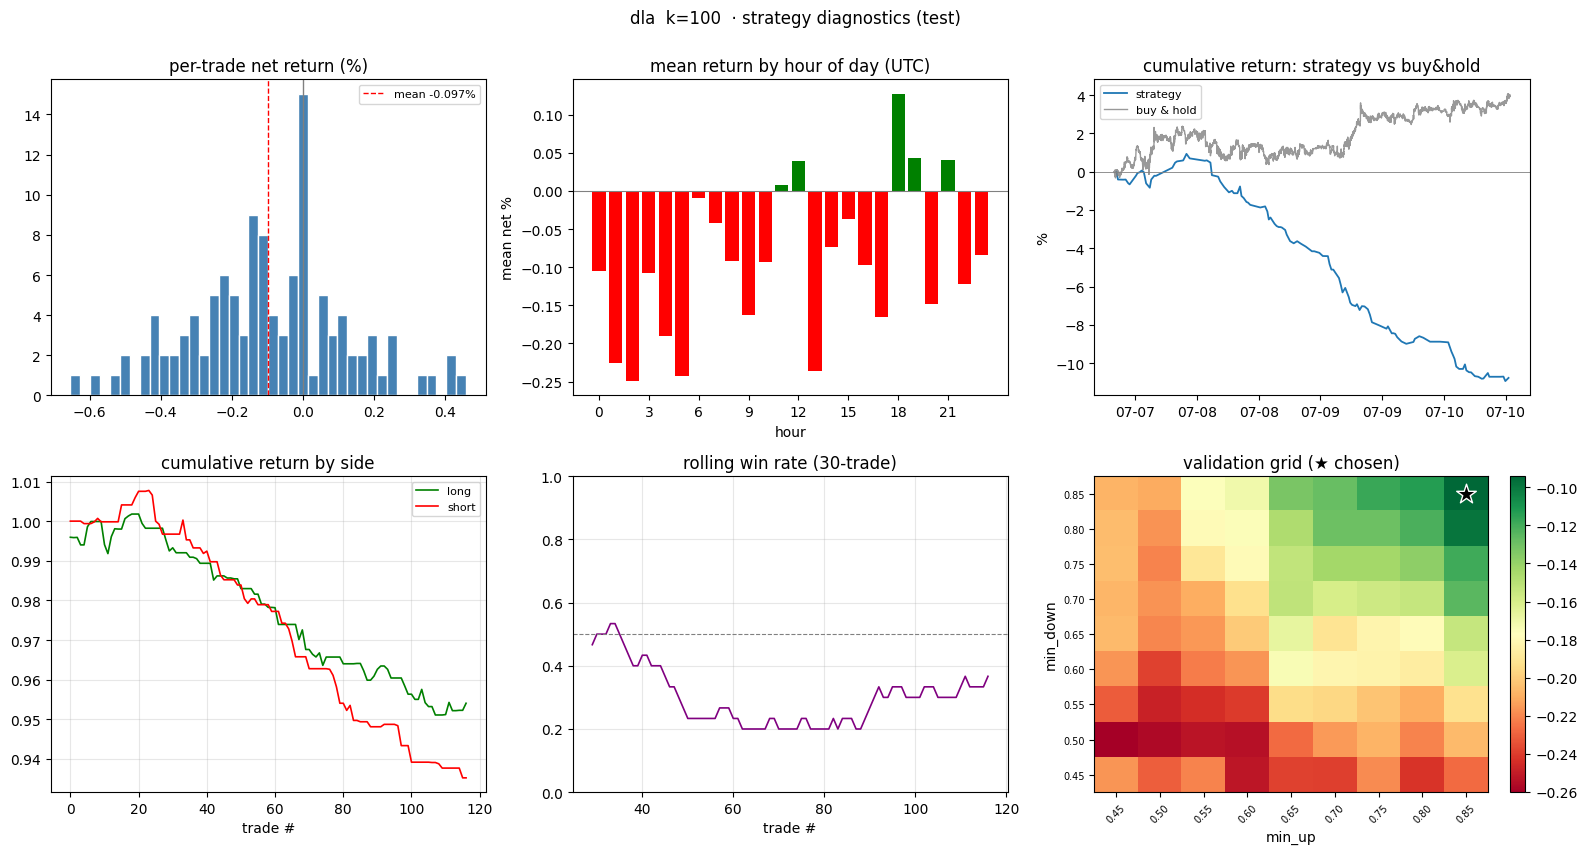

In [34]:
for _, row in selected_df.iterrows():
    tag, k = row["model"], int(row["k"])
    sig = SIGNALS[(tag, k)]["test"]
    mu, md, hold = row["min_up"], row["min_down"], int(row["hold"])
    trades = run_backtest(
        sig["price"], sig["half_spread"], sig["p_up"], sig["p_down"], hold, mu, md
    )
    m, equity, dd = compute_metrics(trades)
    print(
        f"\n=== {tag}  k={k}  (min_up={mu:.2f}, min_down={md:.2f}, hold={hold}) — TEST ==="
    )
    print(
        f"  trades {m['n_trades']} | win {m['win_rate']:.1%} | "
        f"return {m['total_return']:+.2%} | sharpe {m['sharpe']:.2f} | "
        f"maxDD {m['max_drawdown']:.2f}% | buy&hold {row['bh_return']:+.2%}"
    )
    plot_strategy_time(sig, trades, equity, dd, mu, md, hold)
    plot_diagnostics(sig, trades, equity, mu, md)